Breakdown:

potentials.py

solver.py (The main function)

Then, a fourth file, main_app.py, will bring everything together, handle the MediaPipe input, and plot the results.

 # Just an Infinite Potential Square Well


 Ultimately I want:



 - A clean, modular solver that works for **custom 1D potentials**.

 - Later: **GPU acceleration**, nicer **UI**, maybe interactive widgets.



 Technical / numerical TODO:



 - Rigorous boundary-condition (BC) enforcement(Dirichlet for infinite well)

 - Orthonormality diagnostic plots (implemented, but can be refined)

 - Convergence analysis

   - e.g. compare $N = 500$ vs $N = 2000$ to see how the discrete operator $\mathbf{D2}$ behaves

 - Analytic solution benchmarking

   - For the infinite square well: compare $E_n$ to

     $$

     E_n = \frac{\hbar^2 \pi^2 n^2}{2 m L^2}

     $$

 - Documentation + modular design


 ## 1. First-principles thinking about $V(x)$



 I want to keep an intuitive, almost classical picture of what the potential means.



 - $V(x)$ describes the **landscape of potential energy** created by the environment.

   You can think of it as a **height map** or a **hill profile**.



 - If $V(x) = 2$ (some constant), then placing a particle there means:

   - The particle "sits" at potential energy 2 (in whatever units I'm using).

   - To move around with total energy $E$, its kinetic energy is $K = E - V(x)$.

   - So if $V$ is larger, the kinetic energy available is smaller for the same $E$.



 - Intuition:

   - $V(x) = 0$ → flat ground

   - $V(x) = 2$ → you are walking on a slope of "height 2"

   - It's easier to move where $V(x)$ is low than where $V(x)$ is high.



 - If $V(x) = \infty$ in some region, then:

   - A particle would need **infinite total energy** to enter that region.

   - In quantum mechanics, this is enforced by making the wavefunction **exactly zero**

     there: the particle simply **cannot exist** in that region.



 This is exactly how the **infinite square well** is defined.

 ## 2. The infinite square well setup



 I imagine an electron (mass $m$) trapped in an infinite square well:



 - Inside the well, for $0 < x < a$:

   $$

   V(x) = 0

   $$

 - Outside the well:

   $$

   V(x) = \infty

   $$



 So the particle is strictly confined to the region $0 < x < a$.

 ### 2.1 Time-Independent Schrödinger Equation (TISE)



 The time-independent Schrödinger equation is



 $$

 H \Psi(x) = E \Psi(x)

 $$



 with the Hamiltonian



 $$

 H = -\frac{\hbar^2}{2m} \frac{d^2}{dx^2} + V(x)

 $$



 For the infinite well region (where $V(x) = 0$), the TISE reduces to:



 $$

 -\frac{\hbar^2}{2m} \frac{d^2 \Psi}{dx^2} = E \Psi

 $$

 ### 2.2 Boundary conditions and physical constraints



 We enforce some conditions on the wavefunction based on physical requirements:



 - Dirichlet boundary conditions:

   $$

   \Psi(0) = \Psi(a) = 0

   $$



   Reason (continuity argument):

   - Schrödinger's equation requires $\Psi(x)$ to be **continuous**.

   - If $\Psi(x)$ had a jump, its second derivative would involve something like a delta function,

     which would blow up the kinetic energy term.

   - Outside the well, where $V(x) = \infty$, the wavefunction must vanish:

     $$

     \Psi(0^-) = 0, \quad \Psi(a^+) = 0

     $$

   - Continuity then implies

     $$

     \Psi(0^+) = 0, \quad \Psi(a^-) = 0

     $$

     so we simply write $\Psi(0) = \Psi(a)=0$.



 - Normalization:

   $$

   \int_{-\infty}^{\infty} |\Psi(x)|^2 \, dx = 1

   $$

   In practice, for the infinite well, this is

   $$

   \int_0^a |\Psi(x)|^2 \, dx = 1.

   $$



 - Probabilistic interpretation:

   - $|\Psi(x)|^2 \, dx$ is the probability of finding the particle between $x$ and $x + dx$.

 ### 2.3 Known analytic solutions (for checking the numerics later)



 For the infinite square well, the analytic solutions are:



 - Wavefunctions:

   $$

   \Psi_n(x) = \sqrt{\frac{2}{a}} \sin\left(\frac{n \pi x}{a}\right), \quad n = 1, 2, 3, \dots

   $$



 - Energy levels:

   $$

   E_n = \frac{\hbar^2 \pi^2 n^2}{2 m a^2}

   $$



 Later in this notebook, I compare the **numerical eigenvalues** to these $E_n$ as a benchmark.

 ## 3. Discretizing the TISE



 To turn the differential equation into something a computer can solve, I:



 - Break the continuous space into small chunks.

 - Use a finite-difference approximation for derivatives.

 - Build a matrix that mimics the second derivative.

 - Solve the resulting **matrix eigenvalue problem**.



 Let me formalize that.

 ### 3.1 Discretizing the derivative



 We start from the usual definition of the derivative:



 $$

 f'(x_i) = \lim_{\Delta x \to 0} \frac{f(x_i + \Delta x) - f(x_i)}{\Delta x}

 $$



 In the code, I *do not* send $\Delta x$ to 0. Instead:



 - I choose a **fixed** grid spacing $\Delta x$.

 - I approximate the derivative using finite differences.



 For the **first derivative**, a forward-difference formula is



 $$

 f'(x_i) \approx \frac{f(x_{i+1}) - f(x_i)}{\Delta x}.

 $$



 This is called the **forward difference** operator. There are also backward and central differences,

 but for the second derivative we usually like the central difference.

 ### 3.2 Building the second derivative $f''(x_i)$



 Because $\Delta x$ is constant, and derivatives are linear, we can say:



 $$

 f''(x_i) \approx \frac{f'(x_{i+1}) - f'(x_i)}{\Delta x}.

 $$



 Now plug in the finite-difference expressions for $f'$:



 $$

 f'(x_{i+1}) \approx \frac{f(x_{i+2}) - f(x_{i+1})}{\Delta x}, \quad

 f'(x_i) \approx \frac{f(x_{i+1}) - f(x_i)}{\Delta x}

 $$



 so



 $$

 f''(x_i) \approx

 \frac{

 \frac{f(x_{i+1}) - f(x_i)}{\Delta x}

 -

 \frac{f(x_i) - f(x_{i-1})}{\Delta x}

 }

 {\Delta x}

 =

 \frac{f(x_{i+1}) - 2 f(x_i) + f(x_{i-1})}{\Delta x^2}.

 $$



 This is the standard **central difference** formula for the second derivative.



 It is exactly what I will use to approximate the operator $\frac{d^2}{dx^2}$ on a grid.

 ### 3.3 Writing the second derivative as a matrix



 Let the grid points be $x_1, x_2, x_3, x_4, \dots$ and the function values be



 $$

 f(x_i) \rightarrow

 f_i =

 \begin{bmatrix}

 f_1 \\

 f_2 \\

 f_3 \\

 f_4 \\

 \vdots

 \end{bmatrix}.

 $$



 Then the central-difference formula for the second derivative gives:



 $$

 \begin{cases}

 f''_1 = \dfrac{f_2 - 2 f_1 + f_0}{(\Delta x)^2}, \\

 f''_2 = \dfrac{f_3 - 2 f_2 + f_1}{(\Delta x)^2}, \\

 f''_3 = \dfrac{f_4 - 2 f_3 + f_2}{(\Delta x)^2}, \\

 \vdots

 \end{cases}

 $$



 The pattern is a stencil $[1, -2, 1]$ sweeping across the vector.



 In matrix form:



 $$

 \frac{d^2}{dx^2} f(x_i) \approx f''(x_i)

 = \frac{1}{(\Delta x)^2}

 \begin{bmatrix}

 -2 & 1 & 0 & 0 & \cdots \\

 1 & -2 & 1 & 0 & \cdots \\

 0 & 1 & -2 & 1 & \cdots \\

 0 & 0 & 1 & -2 & \cdots \\

 \vdots & \vdots & \vdots & \vdots & \ddots

 \end{bmatrix}

 \begin{bmatrix}

 f_1 \\

 f_2 \\

 f_3 \\

 f_4 \\

 \vdots

 \end{bmatrix}.

 $$

 ### 3.4 Schrödinger equation in matrix form



 Starting from



 $$

 -\frac{\hbar^2}{2m} \frac{d^2}{dx^2} \Psi(x) + V(x) \Psi(x) = E \Psi(x),

 $$



 when we discretize, the kinetic term becomes:



 $$

 -\frac{\hbar^2}{2m} \frac{d^2}{dx^2}

 \;\;\longrightarrow\;\;

 -\frac{\hbar^2}{2m}

 \frac{1}{(\Delta x)^2}

 \begin{bmatrix}

 -2 & 1 & 0 & 0 & \cdots \\

 1 & -2 & 1 & 0 & \cdots \\

 0 & 1 & -2 & 1 & \cdots \\

 0 & 0 & 1 & -2 & \cdots \\

 \vdots & \vdots & \vdots & \vdots & \ddots

 \end{bmatrix}.

 $$



 So the matrix version of the TISE is



 $$

 H \Psi = E \Psi

 $$



 with



 $$

 H =

 -\frac{\hbar^2}{2m}

 \frac{1}{(\Delta x)^2}

 \begin{bmatrix}

 -2 & 1 & 0 & 0 & \cdots \\

 1 & -2 & 1 & 0 & \cdots \\

 0 & 1 & -2 & 1 & \cdots \\

 0 & 0 & 1 & -2 & \cdots \\

 \vdots & \vdots & \vdots & \vdots & \ddots

 \end{bmatrix}

 + \text{diag}\big(V(x_1), V(x_2), \dots \big).

 $$



 Note:



 - This matrix acts on the **internal grid points** from $\Psi_1$ to $\Psi_{N-1}$.

 - The boundary values $\Psi_0$ and $\Psi_N$ are fixed by the **Dirichlet BC**:

   $$

   \Psi_0 = \Psi_N = 0.

   $$

 - So the computer only solves for the interior and the BC is enforced by construction.

 With this theory in place, I now build the actual code.

In [1]:
# Code Begins

import numpy as np
import matplotlib.pyplot as plt


In [2]:
# Grid Parameters

"Limitation: only 0 to L now, not -a to a"
L = 50

N = 2000
#x = np.linspace(0,L,N+1) # N+1, because if you need N intervals we need N+1 end points |..|..|
x = np.linspace(-L/2,L/2,N+2) # For also Wall # N+1, because if you need N intervals we need N+1 end points |..|..|

# x0 , x1 ... xN (Thats N+1 end Points)
dx = x[1] - x[0] # a Constant Width


# Constants in AMU
hbar = 1.0
m = 1.0

Last_k_value = None


In [3]:
# Define Potential

# Potential Play Grounds


#walls_array = []

def constant(x,c):
    """Adds a flat baseline potential."""
    return np.ones_like(x)*c

def harmonic(x,k,center=L/2):
    """A Parabola"""
    global Last_k_value
    Last_k_value = k
    
    constant = 1 #m*L**2
    potential = 0.5*k*(x - center)**2 # Parabola
    
    return constant*potential

def gaussian_well(x, center=L/2, width=1.0, depth=50): # A new Potnetial
    """A dip in the potential (finite well)."""
    return -depth * np.exp(-(x - center)**2 / (2 * width**2))


def custom(x): 
    ""

def inf_sqaure_well(x,lower_bound,upper_bound):
    "Gives you an Infinite square well of Length L"
    "Takes the Grind Points array x and creates an array of Zeros in the same shape"
    ""
    #walls_array.append(lower_bound)
    #walls_array.append(upper_bound)

    V = np.zeros_like(x) 
    V[x<lower_bound] = np.inf # Potnetial of infinite below Lower Bound
    V[x>upper_bound] = np.inf # Potnetial of infinte above upper Bound
    # Effetively, all untouced grind points have potential Zero

    return V

def inf_wall(x,side,bound):
    """
    Places an 'Infinite' wall.
    Instead of np.inf, we use 1e10 (10 billion). This is called Penalty Method
    This forces psi -> 0 without breaking the solver.
    """
    V = np.zeros_like(x)
    HUGE_NUMBER = 9e10 # Replacment for np.inf

    #walls_array.append(bound)
    side = side.strip(', . ').lower() # Becase Strings are immutable and .lower() is a method

    if side =='left':
        # Wall exists everywhere to the left of 'bound'
        V[x<bound] = HUGE_NUMBER

    elif side =='right':
        # Wall exists everywhere to the right of 'bound'
        V[x>bound] = HUGE_NUMBER

    return V


def finite_barrier(x, center, width, height):
    """A square block in the middle.""" # Maybe we can see Tunneling??
    V = np.zeros_like(x)
    mask = (x > (center - width/2)) & (x < (center + width/2))
    V[mask] = height
    return V


def V_double_well(x, depth=20, separation=1):
    V = depth * ( (x-L/2)**2 - separation )**2
    return V



 ### Play Ground for $V(x)$



 Here I choose which potential to use. For now, I will default to the **infinite square well**.



 - I can later uncomment and experiment with:

   - harmonic oscillator + walls,

   - double wells,

   - Gaussian wells,

   - barriers inside wells, etc.

In [4]:
def custom2(x):
    V = np.zeros_like(x)
    return 2

V= inf_sqaure_well(x,-L/2,L/2)


# --- 3. USER PLAYGROUND (Mix and Match Here) ---

# EXAMPLE 1: Half-Harmonic Oscillator (Wall on left, parabola on right)
# V = inf_wall(x, 'left', 2) + harmonic(x, center=5, k=5)

# EXAMPLE 2: A Harmonic Oscillator with a Barrier in the middle
#V = harmonic(x, k=5) + finite_barrier(x, center=L/2, width=0.5, height=50)

# EXAMPLE 3: Double Well (Two Gaussians)
# V = gaussian_well(x, center=3) + gaussian_well(x, center=7)

# Let's run Example 1:
#V = inf_wall(x, 'left', 2) + harmonic(x, center=5, k=5)




[0. 0. 0. ... 0. 0. 0.]


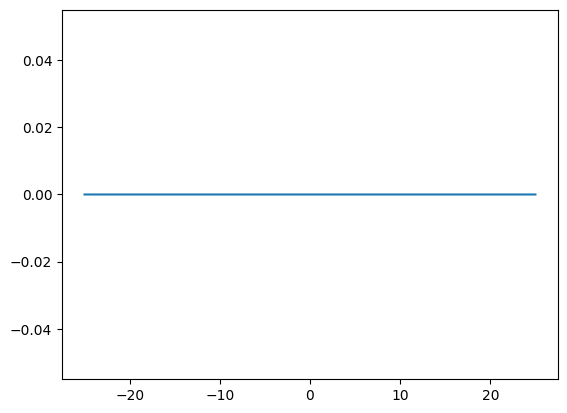

In [5]:
# Debug 

# New Way, to detech Wall while we plot
"""def wall_plot(array):
    for i in range(len(array)):        
        try: 
            plt.axvline(array[i], color='white', lw=2)
            return
        except NameError:
            None"""


print(V)

plt.plot(x,V)
#wall_plot(walls_array)


In [6]:
# The Differntial operator

""" 
Why
Grid: [ Wall, 1, 2, ..., N, Wall ] (Total N+2 items)

Internal Slice: [ 1, 2, ..., N ] (Total N items)

Matrix: N x N

Everything is now synchronized to N=2000.
"""

"Code now Tries the Matrix to have NxN size, on siggestion from Veret Method Professors"


main_diagonal = (1/dx**2)*np.diag(-2*np.ones(N))
off_diagonal1 = (1/dx**2)*np.diag(np.ones(N-1),-1)
off_diagonal2 = (1/dx**2)*np.diag(np.ones(N-1),1)
D2 =  (main_diagonal + off_diagonal1 + off_diagonal2)
# Becase 2 conditions are given, we need the computer to fill in 
# N+1 - 2 =  thats N-1 end points. The main diagonal would have N-1 points
# the Off diagonal would have N-2 points off diagonal points

"""
print(M)
print(M.shape)
"""


'\nprint(M)\nprint(M.shape)\n'

 For an $N \times N$ matrix (e.g. $4 \times 4$ toy example), the pattern is:



 $$

 \begin{bmatrix}

 1 & 1 & 0 & 0  \\

 1 & 2 & 2 & 0  \\

 0 & 2 & 3 & 3  \\

 0 & 0 & 3 & 4  \\

 \end{bmatrix}

 $$



 - Main diagonal: $N$ elements

 - Off diagonals: each has $N-1$ elements



 Here, my actual matrix is the finite-difference approximation to $\dfrac{d^2}{dx^2}$,

 and I then build the Hamiltonian:



 $$

 - \frac{\hbar^2}{2m} \left( \frac{d^2}{dx^2} \right) \Psi = E \Psi

 $$



 turns into



 $$

 H \Psi = E \Psi,

 $$



 where $H$ is built from $D2$ plus the potential.

In [7]:
# Hamiltonian
#T = (-(hbar**2/2*m ) * D2 ) # Recall D is the Differntial Operator 

# Correcting for Python Left to Right Product order
T = (-(hbar**2/(2*m) ) * D2 ) # Recall D is the Differntial Operator 

H = T + np.diag(V[1:-1])


In [8]:
# Solve the Eigen Value Equation

E, psi = np.linalg.eigh(H)  # E is Eigen Value and Psi is Eigen Vector

#psi = psi.T # So we can acess the values by psi[i] ???


 The integral



 $$

 \int_{x_1}^{x_N} f(x)\,dx \approx \sum_{i=1}^{N} f(x_i)\,\Delta x

 $$



 is implemented as a Riemann sum on the grid.

In [9]:
"""# Need to Normalize ???
# We Normalize by making the untegral to go to 1. But we need to make the this again compatible to 
# do in a computer

def integral(f, axis=0):
    return np.sum(f*dx,axis=axis)

norm = integral(psi**2)
psi = psi/np.sqrt(norm)"""


# Apparenlty this is better?

# Normalize each state individually
# psi has shape (N, num_states)
for i in range(psi.shape[1]):
    # 1. Find the integral of probability density
    # sum( |psi|^2 * dx )
    norm_factor = np.sum(psi[:, i]**2) * dx
    
    # 2. Divide the vector by the square root of that integral
    psi[:, i] = psi[:, i] / np.sqrt(norm_factor)


<>:7: SyntaxWarning: invalid escape sequence '\p'
<>:7: SyntaxWarning: invalid escape sequence '\p'
C:\Users\ahila\AppData\Local\Temp\ipykernel_10832\2121740538.py:7: SyntaxWarning: invalid escape sequence '\p'
  plt.plot(x[1:-1], psi[:,n]**2, label = "$\psi_{}$".format(n))


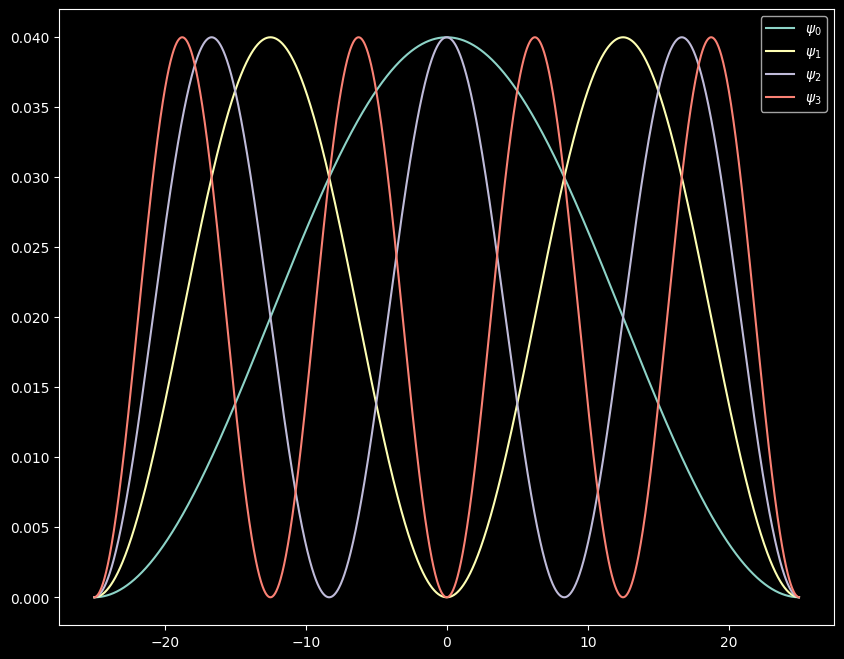

In [10]:
# Plot
plt.style.use("dark_background")
plt.figure(figsize=(10,8))

for n in range(0,4):

    plt.plot(x[1:-1], psi[:,n]**2, label = "$\psi_{}$".format(n))
    plt.legend()


<>:11: SyntaxWarning: invalid escape sequence '\p'
<>:11: SyntaxWarning: invalid escape sequence '\p'
C:\Users\ahila\AppData\Local\Temp\ipykernel_10832\1857151325.py:11: SyntaxWarning: invalid escape sequence '\p'
  label=f"$\psi_{n}^2$  (E={E[n]:.2f})",


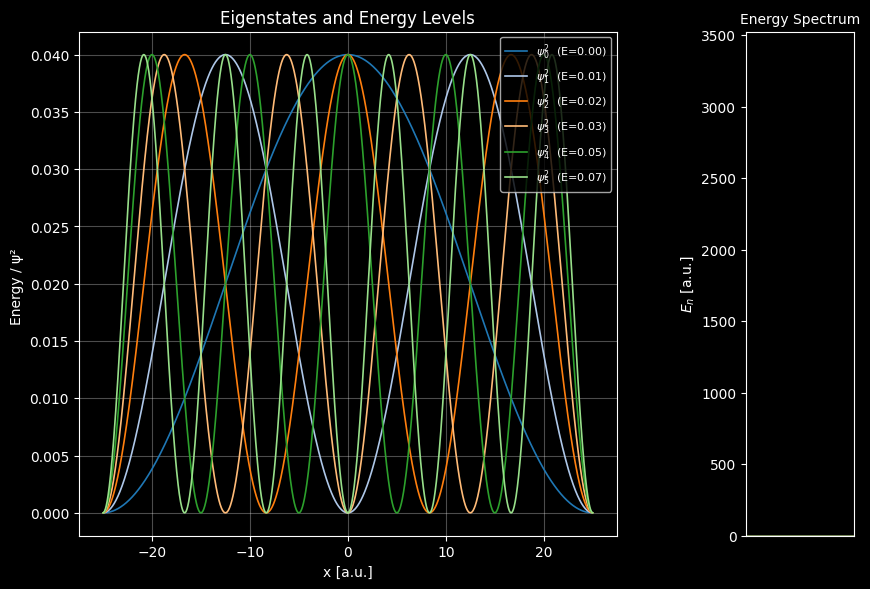

In [11]:
plt.style.use("dark_background")


fig, (ax_main, ax_bar) = plt.subplots(
    1, 2, figsize=(10, 8), gridspec_kw={'width_ratios': [5, 1]})
plt.subplots_adjust(bottom=0.25, wspace=0.4)

for n in range(6):
    ax_main.plot(
        x[1:-1], psi[:, n]**2 , 
        label=f"$\psi_{n}^2$  (E={E[n]:.2f})",
        lw=1.2, # Bigger discrete palette (20 colors)
c = plt.colormaps['tab20'].colors[n % 20] # For unique Matching colour
)

#ax_main.set_xlim(x[1], x[-2])
ax_main.set_xlabel("x [a.u.]")
ax_main.set_ylabel("Energy / ψ² ")
ax_main.set_title("Eigenstates and Energy Levels")
ax_main.legend(loc="upper right", fontsize=8)
ax_main.grid(alpha=0.3)


ax_bar.set_title("Energy Spectrum", fontsize=10)
#ax_bar.set_xlim(0, 1)
ax_bar.set_ylim(0, np.max(E)*1.1)
ax_bar.set_xticks([])
ax_bar.set_ylabel(r"$E_n$ [a.u.]")

for n in range(6):
    ax_bar.axhline(E[n], c = plt.colormaps['tab20'].colors[n % 20]
, lw=1)
plt.show()



In [12]:
# Debug 2
bool(0)
print(E)
E.shape
E[-1]

[1.97392047e-03 7.89567703e-03 1.77652551e-02 ... 3.20318303e+03
 3.20319290e+03 3.20319883e+03]


np.float64(3203.198826079482)

<>:28: SyntaxWarning: invalid escape sequence '\p'
<>:28: SyntaxWarning: invalid escape sequence '\p'
C:\Users\ahila\AppData\Local\Temp\ipykernel_10832\585987316.py:28: SyntaxWarning: invalid escape sequence '\p'
  label=f"$\psi_{n}$  (E={E[n]:.2f})",


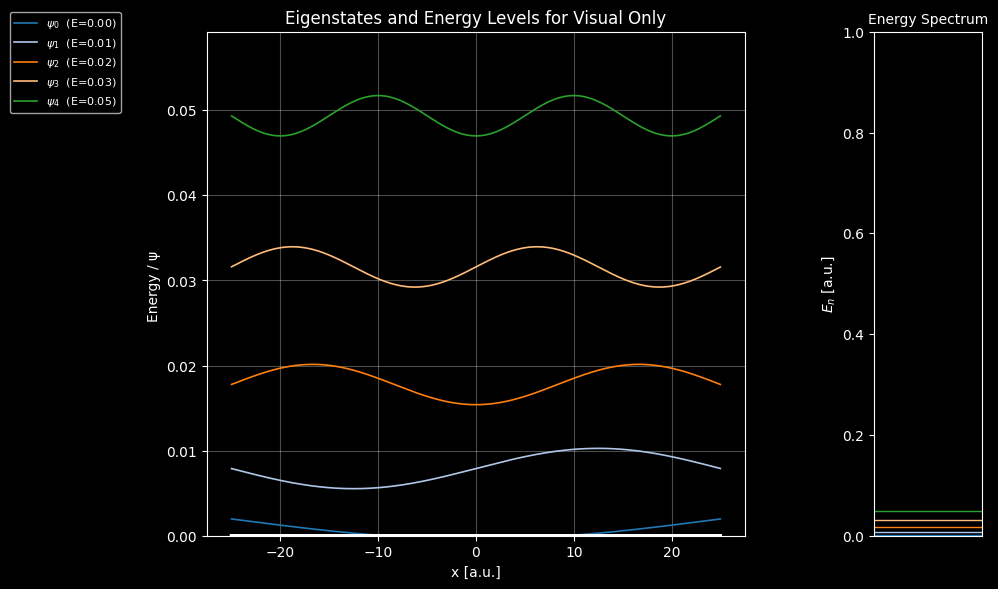

In [13]:
#%matplotlib widget
# Inaccurate Plot for intution (Like the Textbook)

plt.style.use("dark_background")


# The texbook makes a few simplifications, firstly, all of the are vertically shifted with an exaguaration


nos = 5


fig, (ax_main, ax_bar) = plt.subplots(
    1, 2, figsize=(10, 8), gridspec_kw={'width_ratios': [5, 1]})
plt.subplots_adjust(bottom=0.25, wspace=0.4)

#scale = max(psi[:,0])/max(V)
scale = (E[1]-E[0])*0.4

for n in range(nos):
    
    psi_nth = psi[:, n]
    psi_nth = psi_nth / np.max(np.abs(psi_nth))
    vertical_shifted = psi_nth*scale+E[n] ##????    
    
    ax_main.plot(
        x[1:-1], vertical_shifted , 
        label=f"$\psi_{n}$  (E={E[n]:.2f})",
        lw=1.2, # Bigger discrete palette (20 colors)
        c = plt.colormaps['tab20'].colors[n % 20] # For unique Matching colour
    )
    # ax_main.plot(x,V,color='white') # Becase not i am incluindg the infinity into the plot
    # So, i must handel the and then plot, otherwise, my the data would not be visible, 
    # Plot would adjust for the axis and not do be able to show our data, explore also
    # Magic commands. 

    # This is how we now handle is
    # Just like how we usually do ax_main.set_ylim, we are going to d a bit of an 
    # advanced version of that

    # First find the Maximum Height we want

    #window_height = np.max(psi_nth) * 40 # FOr a little Head room
    # The above is giving me one, probably cuz i normalized it???
    window_height = np.max(E[n]) * 2 # FOr a little Head room
    

    V_clipped = np.clip(V,0,window_height) # .clip(array,min array,max array)

    ax_main.plot(x,V_clipped, color='white',lw=2)
    # ax_main.fill_between()




"""
# Plot the Walls
for i in range(len(walls_array)):        
        try: 
            ax_main.axvline(walls_array[i], color='white', lw=2)
        except NameError:
            None
"""
#ax_main.set_xlim(x[1], x[-2])
#ax_main.set_xlim(x[1], 10)

ax_main.set_xlabel("x [a.u.]")
ax_main.set_ylabel("Energy / ψ ")
ax_main.set_ylim(0, np.max(E[n])*1.2)

#ax_main.set_ylim(0,np.max(vertical_shifted)+2)

ax_main.set_title("Eigenstates and Energy Levels for Visual Only")
ax_main.legend(bbox_to_anchor=(-0.15, 1.05), fontsize=8)
ax_main.grid(alpha=0.3)


ax_bar.set_title("Energy Spectrum", fontsize=10)
#ax_bar.set_xlim(0, 1)
ax_bar.set_xticks([])
ax_bar.set_ylabel(r"$E_n$ [a.u.]")

for n in range(nos):
    ax_bar.axhline(E[n], c = plt.colormaps['tab20'].colors[n % 20]
, lw=1)
plt.show()



 ## 4. How do I trust the computer?



 So far:



 - I constructed a Hamiltonian matrix.

 - I asked the computer for its eigenvalues and eigenvectors.

 - I enforced boundary conditions by construction.



 But how do I know these eigenvectors are actually good **approximations to true eigenstates**?



 Two big checks:



 1. **Orthonormality** (linear algebra + normalization)

 2. **Analytic benchmarking** (compare to known formulas)



 ### 4.1 Orthonormality



 If I have two different eigenstates, $\psi_m$ and $\psi_n$ (with $m \neq n$), their inner product must be zero:



 $$

 \langle \psi_m | \psi_n \rangle = 0.

 $$



 This is called **orthogonality**.

 If $m = n$, then the inner product is 1 (if I normalize them properly):



 $$

 \langle \psi_n | \psi_n \rangle = 1.

 $$



 So the **overlap matrix** or **orthonormality matrix** is:



 $$

 \mathbf{S}_{mn} = \langle \psi_m | \psi_n \rangle

 = \int \psi_m^*(x) \psi_n(x) \, dx

 $$



 and in discrete form on the grid:



 $$

 \mathbf{S}_{mn} \approx \sum_i \psi_m(x_i) \psi_n(x_i) \, \Delta x.

 $$



 For properly normalized eigenstates of a Hermitian Hamiltonian, $\mathbf{S}$ should be **the identity matrix**:

 - Diagonal = 1

 - Off-diagonal = 0 (up to small numerical errors)

In [14]:
# --- Orthonormality Check ---
print("Orthonormality Check (First 4 states):")
print("Should be Identity Matrix (approx):")

# We only check the first 4 states (0, 1, 2, 3) as they are the most accurate
CHECK_N = N//100
overlap_matrix = np.zeros((CHECK_N, CHECK_N))

for i in range(CHECK_N):
    for j in range(CHECK_N):
        # Calculate the Reminas Sum: sum(psi_i * psi_j) * dx
        Rsum = np.sum(psi[:, i] * psi[:, j]) * dx
        overlap_matrix[i,j] = Rsum

# Use round to display small numbers clearly


print(overlap_matrix[:3])  # print first few values too


Orthonormality Check (First 4 states):
Should be Identity Matrix (approx):
[[ 1.00000000e+00  1.77546910e-16 -7.54574370e-16 -1.33160183e-16
  -1.55353547e-16 -1.77546910e-16 -2.33030320e-16  1.77546910e-16
   2.77417048e-17 -8.87734552e-17  8.87734552e-17 -4.43867276e-17
  -3.05158752e-17  6.65800914e-17  1.38708524e-17 -3.32900457e-17
   0.00000000e+00 -1.66450229e-17  5.54834095e-18 -2.77417048e-17]
 [ 1.77546910e-16  1.00000000e+00 -1.77546910e-16  1.77546910e-16
   1.99740274e-16  6.76897596e-16 -4.10577230e-16  1.58682551e-15
   2.49675343e-16  2.85739559e-16  5.54834095e-18  4.43867276e-17
  -6.10317505e-17  3.93932208e-16 -1.10966819e-17  5.82575800e-16
  -4.43867276e-17  2.63546195e-16 -5.54834095e-18  4.99350686e-17]
 [-7.54574370e-16 -1.77546910e-16  1.00000000e+00  8.87734552e-17
  -1.99740274e-15 -1.99740274e-16  1.31495681e-15 -5.88124141e-16
  -1.07637814e-15  1.10966819e-17 -2.57997854e-16  2.21933638e-17
   4.10577230e-16 -1.55353547e-16 -3.77287185e-16 -3.32900457e-17

In [15]:
print(np.round(overlap_matrix, 10))

[[ 1.  0. -0. -0. -0. -0. -0.  0.  0. -0.  0. -0. -0.  0.  0. -0.  0. -0.
   0. -0.]
 [ 0.  1. -0.  0.  0.  0. -0.  0.  0.  0.  0.  0. -0.  0. -0.  0. -0.  0.
  -0.  0.]
 [-0. -0.  1.  0. -0. -0.  0. -0. -0.  0. -0.  0.  0. -0. -0. -0. -0. -0.
   0.  0.]
 [-0.  0.  0.  1. -0. -0. -0. -0. -0.  0. -0. -0.  0.  0.  0. -0. -0.  0.
   0. -0.]
 [-0.  0. -0. -0.  1.  0.  0. -0.  0. -0. -0.  0.  0. -0. -0. -0. -0. -0.
   0.  0.]
 [-0.  0. -0. -0.  0.  1.  0. -0. -0. -0. -0.  0.  0. -0. -0. -0. -0. -0.
   0.  0.]
 [-0. -0.  0. -0.  0.  0.  1. -0. -0.  0.  0.  0.  0.  0.  0. -0.  0.  0.
   0.  0.]
 [ 0.  0. -0. -0. -0. -0. -0.  1.  0. -0.  0.  0.  0.  0. -0. -0.  0.  0.
   0.  0.]
 [ 0.  0. -0. -0.  0. -0. -0.  0.  1.  0. -0.  0.  0.  0. -0. -0. -0. -0.
   0.  0.]
 [-0.  0.  0.  0. -0. -0.  0. -0.  0.  1.  0.  0. -0.  0. -0.  0. -0.  0.
  -0. -0.]
 [ 0.  0. -0. -0. -0. -0.  0.  0. -0.  0.  1.  0. -0.  0.  0. -0.  0. -0.
  -0. -0.]
 [-0.  0.  0. -0.  0.  0.  0.  0.  0.  0.  0.  1. -0.  0.  0. -0.

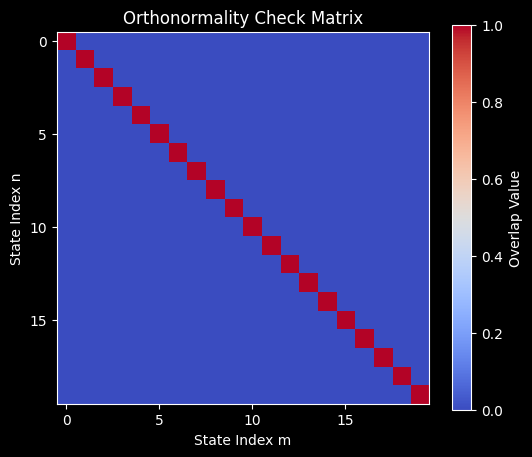

In [16]:
from matplotlib.ticker import MultipleLocator # Import the locator class


plt.figure(figsize=(6,5))
plt.imshow(overlap_matrix, cmap='coolwarm', origin='lower')
plt.colorbar(label="Overlap Value")
plt.title("Orthonormality Check Matrix")
plt.xlabel("State Index m")
plt.ylabel("State Index n")
#plt.grid()
plt.gca().invert_yaxis()
plt.locator_params(axis='y', integer=True)
plt.locator_params(axis='x', integer=True)
#plt.gca().yaxis.set_major_locator(MultipleLocator(1))
#plt.gca().xaxis.set_major_locator(MultipleLocator(1))

plt.show()

 ## 5. Analytical tests (benchmarking)



 Orthonormality tells me the eigenvectors make sense **as a basis**, but I still want to know:



 > Are these the *correct* eigenstates for **this** potential?



 For that, I compare:



 - The **numerical** energy levels from the matrix diagonalization.

 - The **analytic** formulas I already know:

   - Infinite square well energy spectrum.

   - (Optionally) harmonic oscillator spectrum when I switch potential.



 ---



 ### 5.1 Indexing remark



 - In physics, the ground state is $E(n = 1)$ for the infinite square well.

 - In Python, array indices start at 0.



 So:



 - Physically: $n = 1, 2, 3, \dots$

 - In code: `i = 0, 1, 2, ...` corresponds to $n = i + 1$.



 This mismatch is annoying but standard in programming.

 ### 5.2 Infinite square well energies



 The analytic formula:



 $$

 E_{n}^{\text{analytic}} = \frac{\hbar^2 \pi^2 n^2}{2 m L^2}

 $$



 (Here $L$ is the well width.)

In [17]:
CHECK_N = CHECK_N

E_numerical = E[:CHECK_N]

E_analytic = np.zeros(CHECK_N+1)

for i in range(CHECK_N):
    n = i + 1 
    # n = i 
    
    E_analytic[i] = (hbar**2 * np.pi**2 * n**2 ) / (2*m*L**2)


# --- RESULTS ---
print("\n### ENERGY BENCHMARK: Infinite Square Well ###")
print("-" * 55)
print(f"| n | Analytic E | Numerical E | % Error |")
print("-" * 55)

for i in range(CHECK_N):
    percent_error = np.abs((E_numerical[i] - E_analytic[i]) / E_analytic[i]) * 100
    
    print(
        f"| {i+1:<1} | {E_analytic[i]:<10.6f} | {E_numerical[i]:<11.6f} | {percent_error:<7.4f}% |"
    )

print("-" * 55)



### ENERGY BENCHMARK: Infinite Square Well ###
-------------------------------------------------------
| n | Analytic E | Numerical E | % Error |
-------------------------------------------------------
| 1 | 0.001974   | 0.001974    | 0.0000 % |
| 2 | 0.007896   | 0.007896    | 0.0001 % |
| 3 | 0.017765   | 0.017765    | 0.0002 % |
| 4 | 0.031583   | 0.031583    | 0.0003 % |
| 5 | 0.049348   | 0.049348    | 0.0005 % |
| 6 | 0.071061   | 0.071061    | 0.0007 % |
| 7 | 0.096722   | 0.096721    | 0.0010 % |
| 8 | 0.126331   | 0.126329    | 0.0013 % |
| 9 | 0.159888   | 0.159885    | 0.0017 % |
| 10 | 0.197392   | 0.197388    | 0.0021 % |
| 11 | 0.238844   | 0.238838    | 0.0025 % |
| 12 | 0.284245   | 0.284236    | 0.0030 % |
| 13 | 0.333593   | 0.333581    | 0.0035 % |
| 14 | 0.386888   | 0.386873    | 0.0040 % |
| 15 | 0.444132   | 0.444112    | 0.0046 % |
| 16 | 0.505324   | 0.505297    | 0.0053 % |
| 17 | 0.570463   | 0.570429    | 0.0059 % |
| 18 | 0.639550   | 0.639508    | 0.0067 

## Convergence Test



In [18]:
# COnvergence Test



 ### 5.3 Harmonic oscillator benchmark



 When I switch $V(x)$ to a harmonic oscillator $V(x) = \tfrac{1}{2} k (x-x_0)^2$ and run the solver:



 - The analytic energy levels are

   $$

   E_n^{\text{HO}} = \left(n + \frac{1}{2}\right) \hbar \omega

   $$

   where $\omega = \sqrt{k/m}$ and $n = 0, 1, 2, \dots$.



 - I can compare the numerical $E_n$ to those values.

 - This is a good **second** test after the infinite square well.

In [19]:
# Assuming Last_k_value, hbar, m, E, and CHECK_N are available

try: 
    k = Last_k_value
    if k is None:
        print("ERROR: k is not set. Run a harmonic potential first.")
        # Optional: Add an 'except' block to handle the potential division by zero
    
    # Calculate Omega once
    w = np.sqrt(k/m)

    E_numerical = E[:CHECK_N]
    E_analytic = np.zeros(CHECK_N)

    # --- FIX IS HERE ---
    for i in range(CHECK_N):
        # i is the correct quantum number n for the HO formula (i=0 is ground state)
        n_quantum = i 
        
        # Formula: (n + 0.5) * hbar * w
        E_analytic[i] = (n_quantum + 0.5 ) * hbar * w


    # --- RESULTS ---
    print("\n### ENERGY BENCHMARK: Harmonic Oscillator ###")
    print("-" * 55)
    print(f"| n | Analytic E | Numerical E | % Error |")
    print("-" * 55)

    for i in range(CHECK_N):
        # We print n=i+1 because the physical state labels start at 1
        n_label = i + 1 
        
        percent_error = np.abs((E_numerical[i] - E_analytic[i]) / E_analytic[i]) * 100
        
        print(
            f"| {n_label:<1} | {E_analytic[i]:<10.6f} | {E_numerical[i]:<11.6f} | {percent_error:<7.4f}% |"
        )

    print("-" * 55)

except Exception as e:
    
    print(f"I don't think this is a Harmonic Osscilator ","\n or")

    print(f"An error occurred during benchmark calculation: {e}")


ERROR: k is not set. Run a harmonic potential first.
I don't think this is a Harmonic Osscilator  
 or
An error occurred during benchmark calculation: unsupported operand type(s) for /: 'NoneType' and 'float'
